In [1]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

Run 53 imported


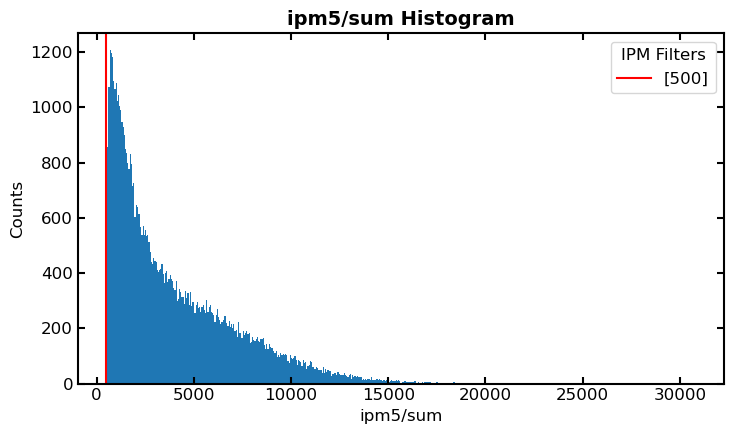

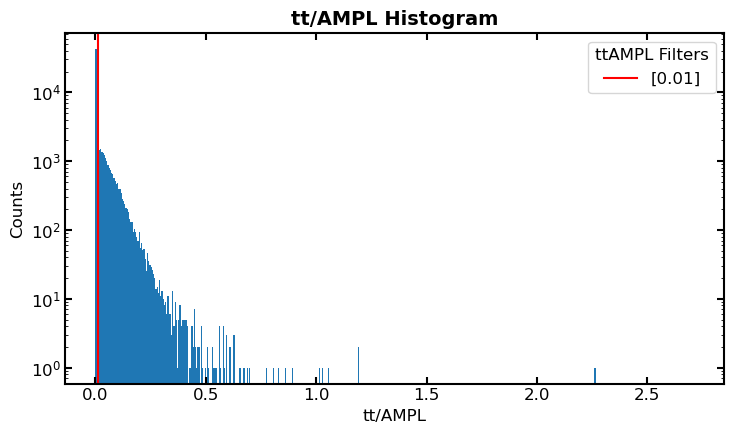

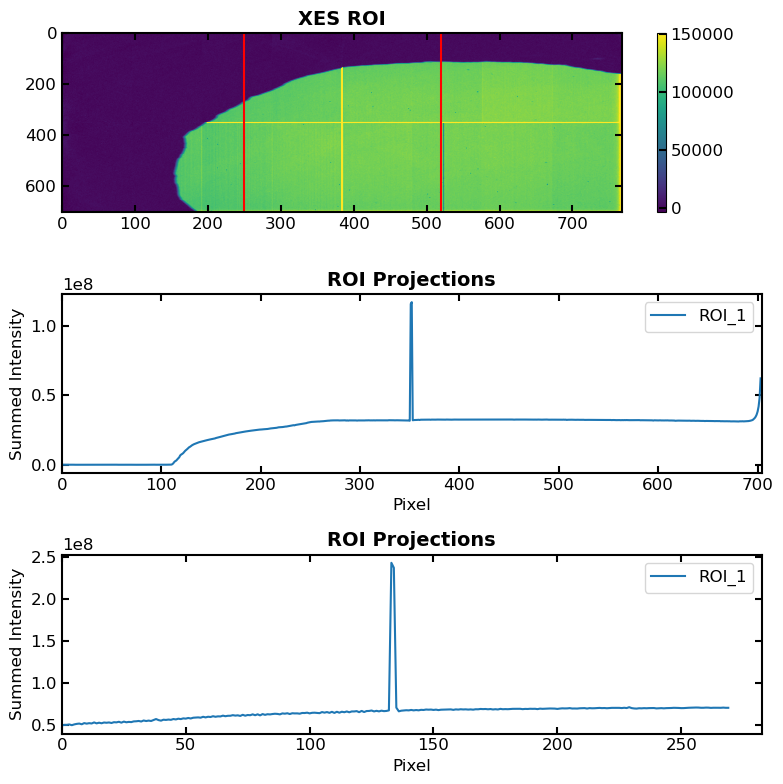

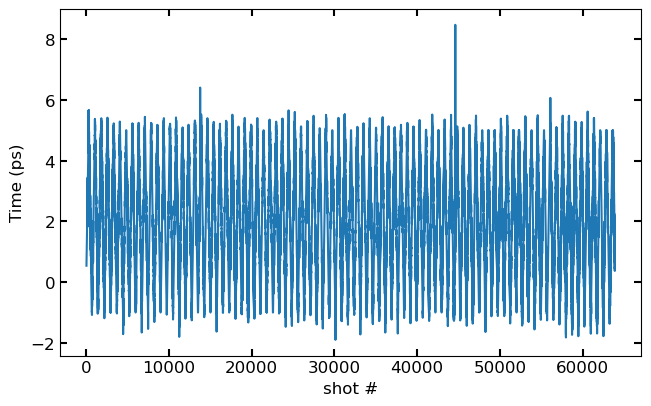

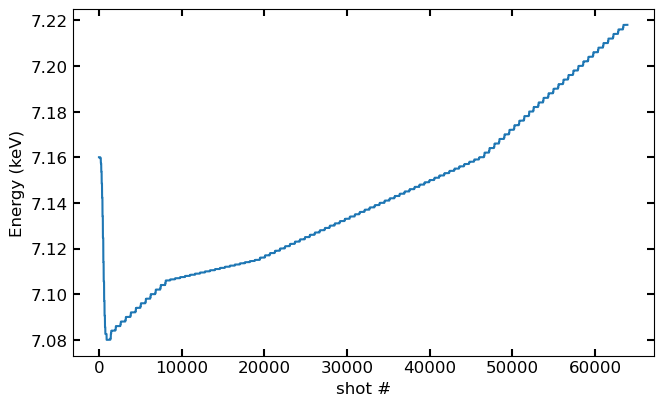

In [2]:
run = 53
exp = 'xcs101632226'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm5/sum','tt/AMPL', 'epix_2/ROI_area'] 
names=['energy','energy_E_setpoint','time_tool_correction','lxt'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [500]

d.ipm_histogram(ipm_thres)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

adu_thres = [6]
# d.adu_histogram(nshots, adu_thres)

ka_roi_d = [250, 520]
kb_roi_d = [180, 220]

d.detector_sum_ROI(ka_roi_d)

# d.xas_ROI(nshots, horiz_limits=[10, 360], vert_limits=[20,340])

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt']][:]*1e12 + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
# plt.ylim([0, 5])
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

# pdf.close()

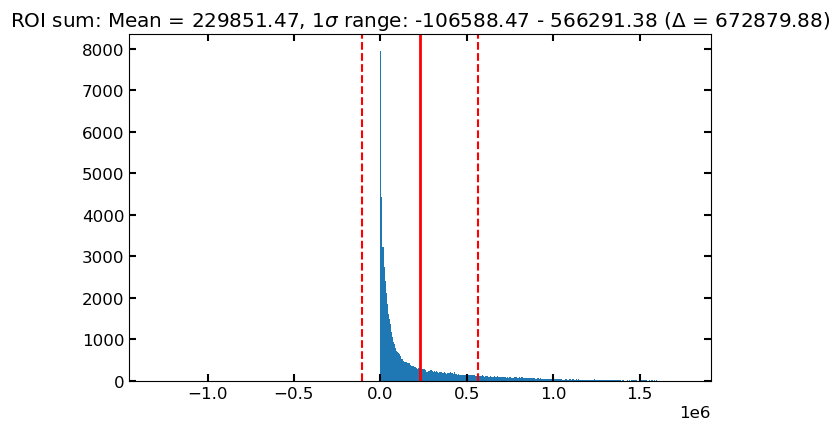

In [3]:
shotmask = (d.h5[d.datadict['ipm']][:] > ipm_thres[0])
data_filt = d.h5['epix_2']['ROI_sum'][shotmask]
data_filt_mean = np.nanmean(data_filt)
data_filt_std = np.nanstd(data_filt)
xmin = np.nanmin(data_filt)
xmax = np.nanmax(data_filt)
binstep = (xmax - xmin)/500

fig, ax = plt.subplots(ncols = 1)

ax.hist(data_filt, bins = np.arange(xmin, xmax, binstep));
# ax.set_xlabel('Delay (ps)')
ax.set_xlim([data_filt_mean - 5*data_filt_std, data_filt_mean + 5*data_filt_std])
ax.axvline(data_filt_mean, color = 'r', linewidth = 2)
ax.axvline(data_filt_mean - data_filt_std, color = 'r', linestyle = '--')
ax.axvline(data_filt_mean + data_filt_std, color = 'r', linestyle = '--')
ax.set_title(r'ROI sum: Mean = %.2f, 1$\sigma$ range: %.2f - %.2f ($\Delta$ = %.2f)' % (data_filt_mean, data_filt_mean - data_filt_std, data_filt_mean + data_filt_std, 2*data_filt_std));

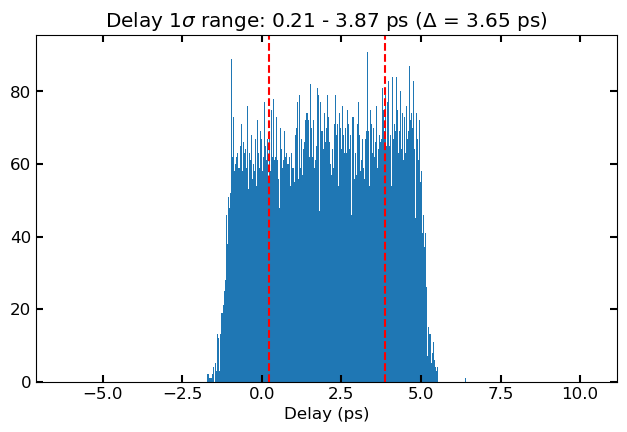

In [4]:
shotmask = (d.h5[d.datadict['ipm']][:] > ipm_thres[0]) & (d.h5[d.datadict['time_tool_ampl']][:] > tt_thres[0])
data_filt = delay[shotmask]
data_filt_mean = np.nanmean(data_filt)
data_filt_std = np.nanstd(data_filt)
xmin = np.nanmin(data_filt)
xmax = np.nanmax(data_filt)
binstep = (xmax - xmin)/500

fig, ax = plt.subplots(ncols = 1)

ax.hist(data_filt, bins = np.arange(xmin, xmax, binstep));
ax.set_xlabel('Delay (ps)')
ax.set_xlim([data_filt_mean - 5*data_filt_std, data_filt_mean + 5*data_filt_std])
ax.axvline(data_filt_mean - data_filt_std, color = 'r', linestyle = '--')
ax.axvline(data_filt_mean + data_filt_std, color = 'r', linestyle = '--')
ax.set_title(r'Delay 1$\sigma$ range: %.2f - %.2f ps ($\Delta$ = %.2f ps)' % (data_filt_mean - data_filt_std, data_filt_mean + data_filt_std, 2*data_filt_std));

### XANES 2D Energy

In [5]:
arr_3d = np.array([
    [[1, 2, 3], [4, 5, 6]], # First 2D matrix
    [[7, 8, 9], [10, 11, 12]], # Second 2D matrix
    [[2, 3, 2], [3, 8, 22]] # Third 2D matrix
])
arr_1d = np.array([1,2,3])
print(arr_3d[0])
print(arr_1d[0])

print(np.nanstd(arr_3d, axis = 0))

[[1 2 3]
 [4 5 6]]
1
[[2.62466929 2.62466929 3.09120617]
 [3.09120617 2.44948974 6.59966329]]


In [12]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['energy','energy_E_setpoint','time_tool_correction','lxt_ttc'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##

xes1.mintime = -1 # ps
xes1.maxtime = 5 # ps
xes1.time_step = 0.2 # ps
xes1.time_bins  = np.arange(xes1.mintime, xes1.maxtime+xes1.time_step, xes1.time_step)
xes1.set_key_aliases(keys,names)

xes1.add_filter('xray','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','ipm',ipm_thres[0])
xes1.add_filter('simultaneous','time_tool_ampl',tt_thres[0])
xes1.scattering = True

# xes1.energy_bins = np.concatenate([np.arange(7.080,7.110,0.002), np.arange(7.111,7.115,0.00025), np.arange(7.116,7.160,0.001), np.arange(7.160,7.220,0.002)])
np.concatenate([np.arange(7.080,7.104,0.002), np.arange(7.106,7.11525,0.0005), np.arange(7.116,7.159,0.001), np.arange(7.160,7.220,0.002)])

xes1.run_parser(['53-54 56-64'])
# xes1.run_parser(['56-61'])

In [13]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = False)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Analysis completed: 15.68 s


In [14]:
elist2 = np.concatenate([np.arange(7.080,7.104,0.002), np.arange(7.106,7.11525,0.0005), np.arange(7.116,7.159,0.001), np.arange(7.160,7.220,0.002)])
# print(elist2)
# print(elist2.shape)

/lscratch/rribson/tmp/ipykernel_3590868/2374427964.py:16: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_time_energy_binned/run.ipm_xray_not_laser_time_energy_binned
/lscratch/rribson/tmp/ipykernel_3590868/2374427964.py:17: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm  = run.epix_simultaneous_laser_time_energy_binned/run.ipm_simultaneous_laser_time_energy_binned
/lscratch/rribson/tmp/ipykernel_3590868/2374427964.py:27: RuntimeWarning: Mean of empty slice
  ax[plt_indx0].plot(run.energy_bins, np.nanmean(xas_lon_norm, axis = 0), label = 'Mean Laser On')
/lscratch/rribson/tmp/ipykernel_3590868/2374427964.py:26: RuntimeWarning: Mean of empty slice
  ax[plt_indx0].plot(run.energy_bins, np.nanmean(xas_loff_norm, axis = 0), label = 'Mean Laser Off')
/lscratch/rribson/tmp/ipykernel_3590868/2374427964.py:56: RuntimeWarning: Mean of empty slice
  xas_lon_mean  = np.nanmean(xas_lon_all, axis=0)


Text(0.5, 1.0, 'Average of Runs')

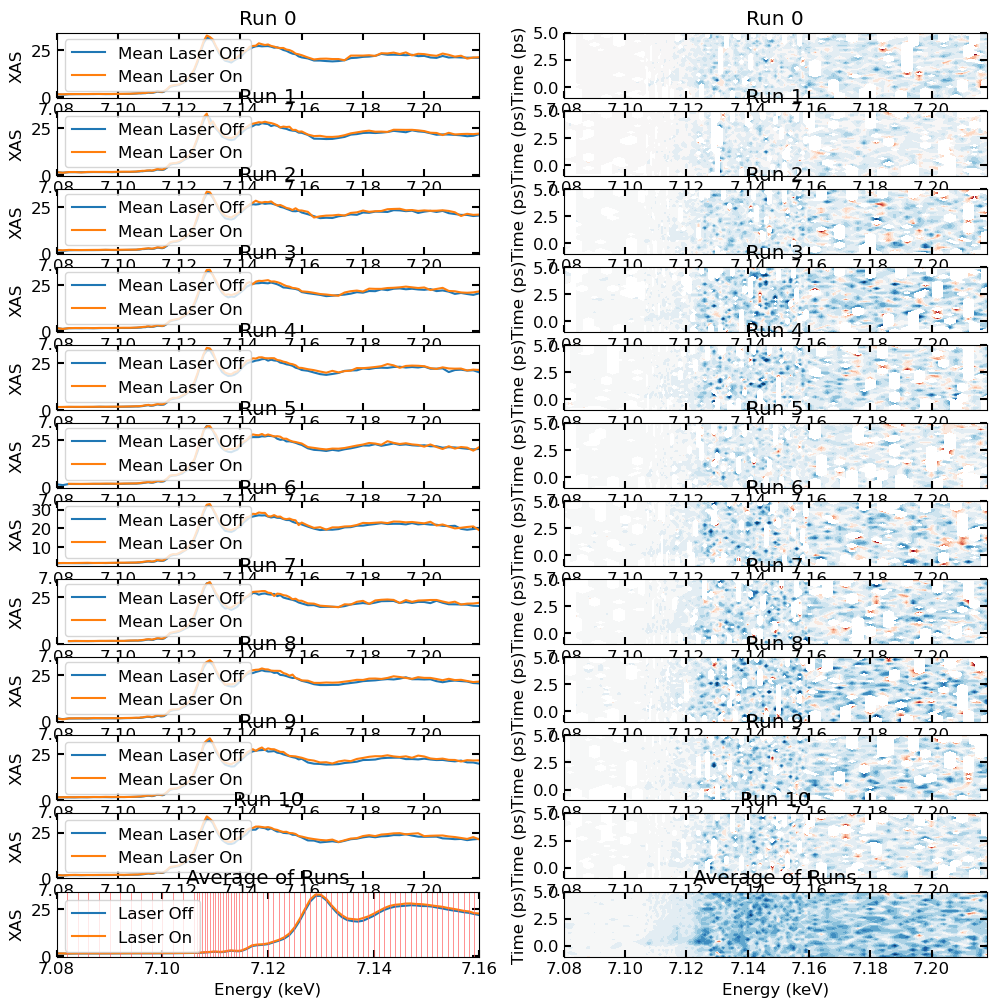

In [15]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    # print(ii)
    # print(run.energy_bins.shape)
    # print(run.epix_simultaneous_laser_time_energy_binned.shape)
    # print(run.epix_xray_not_laser_time_energy_binned.shape)
    run_count+=1

fig, ax = plt.subplots(figsize = (12,12), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_lon_all  = []

for ii, run in enumerate(xes1.analyzed_runs):

    xas_loff_norm = run.epix_xray_not_laser_time_energy_binned/run.ipm_xray_not_laser_time_energy_binned
    xas_lon_norm  = run.epix_simultaneous_laser_time_energy_binned/run.ipm_simultaneous_laser_time_energy_binned
    xas_diff_norm = np.subtract(xas_lon_norm, xas_loff_norm)

    xas_loff_all.append(xas_loff_norm)
    xas_lon_all.append(xas_lon_norm)

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.energy_bins, np.nanmean(xas_loff_norm, axis = 0), label = 'Mean Laser Off')
    ax[plt_indx0].plot(run.energy_bins, np.nanmean(xas_lon_norm, axis = 0), label = 'Mean Laser On')
    ax[plt_indx0].set_xlim([np.min(run.energy_bins), np.max(run.energy_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    vmax = np.nanmax(np.abs(xas_diff_norm))
    vmin = -vmax
    contlevels = np.linspace(vmin*0.75, vmax*0.75, 20)

    ax[plt_indx1].contourf(run.energy_bins, xes1.time_bins, xas_diff_norm, contlevels, cmap = 'RdBu')
    # ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    # ax[plt_indx1].set_xlim([np.min(run.energy_bins), np.max(run.energy_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'Time (ps)')
    ax[plt_indx1].set_title('Run %i' % ii)
    # ax[plt_indx1].minorticks_on()
    # ax[plt_indx1].grid(which = 'both')


# ===== Compute mean and SEM =====
xas_loff_all = np.array(xas_loff_all)
xas_lon_all  = np.array(xas_lon_all)

# N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].energy_bins

xas_loff_mean = np.nanmean(xas_loff_all, axis=0)
xas_lon_mean  = np.nanmean(xas_lon_all, axis=0)

# xas_loff_sem = np.nanstd(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
# xas_lon_sem  = np.nanstd(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_diff_mean = xas_lon_mean - xas_loff_mean
# xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)


# # ===== Final row with error bars =====
plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].plot(run.energy_bins, np.nanmean(xas_loff_mean, axis = 0), label = 'Laser Off')
ax[plt_indx0_sum].plot(run.energy_bins, np.nanmean(xas_lon_mean, axis = 0), label = 'Laser On')

# elist2 = np.concatenate([np.arange(7.080,7.109,0.002), np.arange(7.110,7.11525,0.00025), np.arange(7.116,7.159,0.001), np.arange(7.160,7.220,0.002)])
for ii in np.arange(elist2.shape[0]):
    ax[plt_indx0_sum].axvline(elist2[ii], color = np.array([255, 100, 100])/255, linewidth = 0.5)
ax[plt_indx0_sum].set_xlim([np.min(run.energy_bins), np.max(run.energy_bins)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
ax[plt_indx0_sum].set_xlim([7.08, 7.16])

vmax = np.nanmax(np.abs(xas_diff_mean))
vmin = -vmax
contlevels = np.linspace(vmin*0.75, vmax*0.75, 20)

ax[plt_indx1_sum].contourf(run.energy_bins, xes1.time_bins, xas_diff_mean, contlevels, cmap = 'RdBu')
# ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
# ax[plt_indx1].set_xlim([np.min(run.energy_bins), np.max(run.energy_bins)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'Time (ps)')
ax[plt_indx1_sum].set_title('Average of Runs')


In [16]:
time_axis = xes1.time_bins
t0indx = np.argmin(np.abs(time_axis - 0.5))

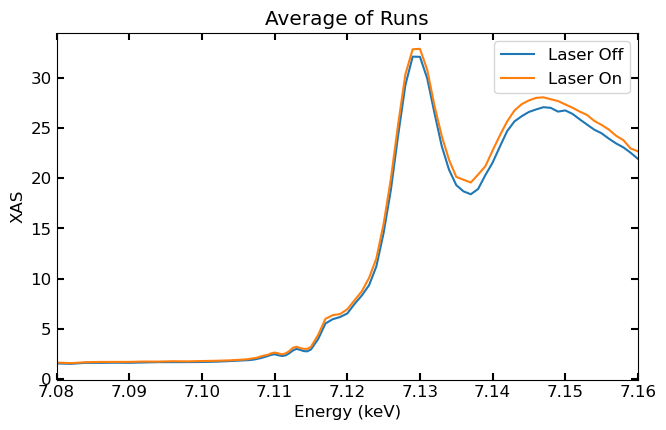

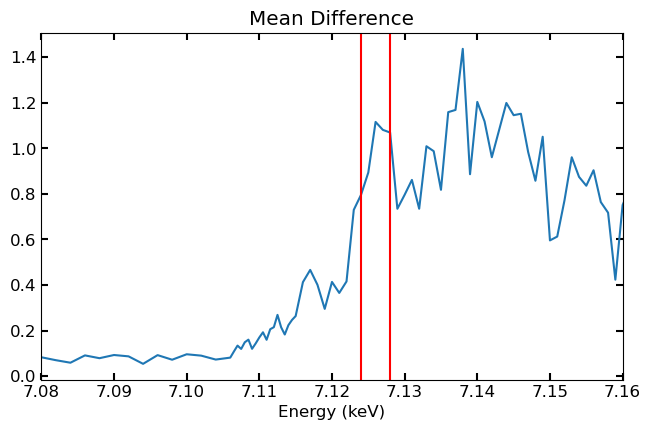

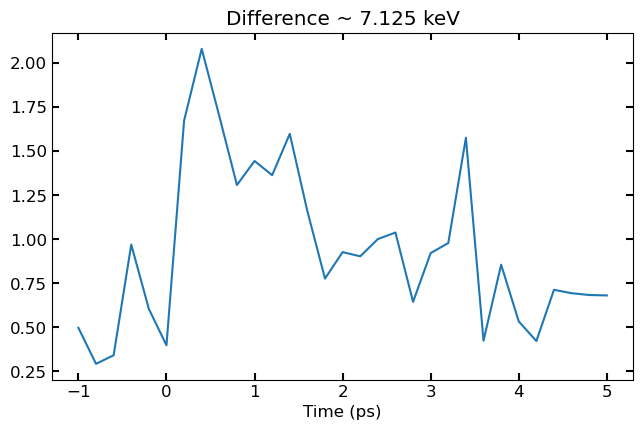

In [17]:
plt.plot(run.energy_bins, np.nanmean(xas_loff_mean[t0indx:,:], axis = 0), label = 'Laser Off')
plt.plot(run.energy_bins, np.nanmean(xas_lon_mean[t0indx:,:], axis = 0), label = 'Laser On')

# elist2 = np.concatenate([np.arange(7.080,7.109,0.002), np.arange(7.110,7.11525,0.00025), np.arange(7.116,7.159,0.001), np.arange(7.160,7.220,0.002)])
# for ii in np.arange(elist2.shape[0]):
#     ax[plt_indx0_sum].axvline(elist2[ii], color = np.array([255, 100, 100])/255, linewidth = 0.5)
plt.xlim([np.min(run.energy_bins), np.max(run.energy_bins)])
plt.xlabel('Energy (keV)')
plt.ylabel('XAS')
plt.legend()
plt.title('Average of Runs')
plt.xlim([7.08, 7.16])
plt.show()

emin = 7.124
emax = 7.128
plt.plot(energy_axis, np.nanmean(xas_diff_mean[t0indx:,:], axis = 0))
plt.axvline(emin, color = 'r')
plt.axvline(emax, color = 'r')
plt.title('Mean Difference')
plt.xlabel('Energy (keV)')
plt.xlim([7.08, 7.16])
plt.show()

emindx = np.argmin(np.abs(energy_axis - emin))
emaxdx = np.argmin(np.abs(energy_axis - emax))

plt.plot(time_axis, np.nanmean(xas_diff_mean[:,emindx:emaxdx], axis = 1))
plt.title('Difference ~ 7.125 keV')
plt.xlabel('Time (ps)')
plt.show()